In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Definitions

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

import numpy as np
from scipy.sparse import bmat, diags, block_diag
from scipy.sparse import dok_array, bmat, diags
from scipy.sparse.linalg import expm_multiply

from lattice import Graphene
# class Graphene:

#   def __init__(self, nmax, onsite_energy=(0,0), J = 1., J_prime = 0,pbc=None):
#     self.nmax = nmax
#     self.mid_point = np.array([nmax - 1, nmax-1], dtype=int) / 2
#     self.la = self.lb = nmax ** 2
#     self.onsite_energy = {"A": onsite_energy[0], "B": onsite_energy[1]}
#     self.J = J
#     self.J_prime = J_prime

#     if pbc not in ["x", "y", "xy", None]:
#         raise Exception("The PBC conditions can be only 'x' , 'y' or 'xy'." )

#     self.pbc = pbc
    
#     self.coord_map = self._create_coordinates_map(shape=(nmax, nmax))


#   def _generate_block_Hab_non_pbc(self):
#     ks = [0, 1, self.nmax]

#     diagonals = [np.full(self.la, -self.J) for k in ks]
#     diagonals[1][self.nmax - 1 :: self.nmax] = 0.

#     return diags(diagonals, ks)

#   def _generate_block_Hab_pbc(self):
#     non_pbc_part = self._generate_block_Hab_non_pbc()

#     if self.pbc == "x":
#         offset = -self.nmax + 1
#         extra_diagonals = np.zeros((self.nmax ** 2) - (self.nmax - 1))
#         extra_diagonals[::self.nmax] = -self.J

#         other_diagonals = diags(extra_diagonals, offset, shape=(self.la, self.la))

#         return non_pbc_part + other_diagonals

#     if self.pbc == "y":
#         offset = -self.la + self.nmax
#         extra_diagonals = np.full(self.nmax, -self.J)
#         other_diagonals = diags(extra_diagonals, offset, shape=(self.la, self.la))

#         return non_pbc_part + other_diagonals

#     if self.pbc == "xy":
#         offset = [-self.la + self.nmax, -self.nmax + 1]

#         # Y part
#         y_part = np.full(self.nmax, -self.J)

#         # X part
#         x_part = np.zeros((self.nmax ** 2) - (self.nmax - 1))
#         x_part[::self.nmax] = -self.J
#         extra_diagonals = [
#           y_part,
#           x_part
#         ]

#         other_diagonals = diags(extra_diagonals, offset, shape=(self.la, self.la))

#         return non_pbc_part + other_diagonals

#   def _generate_main_diag_block(self, site):
#     energy = self.onsite_energy[site]
#     n = self.num_sites(site)
    
#     if not self.J_prime:
#       onsite_energies_diag = np.full(n, energy)
#       return diags(onsite_energies_diag)
    
#     if not self.pbc:
#       ks = [1, self.nmax - 1, self.nmax]

#       k = [self._build_diag_for_NNN(ki, n) for ki in ks]

#       diag = [energy] + k * 2
#       offsets = [0] + ks + [-ki for ki in ks]

#       return diags(diag, offsets=offsets)

#   def _build_diag_for_NNN(self, ki, n):
#     k = np.full(n - ki, self.J_prime)

#     if ki == 1:
#       k[self.nmax-1::self.nmax] = 0
#       return k

#     if ki == self.nmax - 1:
#       k[::self.nmax] = 0
#       return k
    
#     return k

#   def num_sites(self, kind="all") -> int:
#     match kind.upper():
#       case "A":
#         return self.la
#       case "B":
#         return self.lb
#       case "ALL":
#         return self.la + self.lb
#       case _:
#         return None

#   @property
#   def hamiltonian(self):
#     if self.pbc:
#       Hab = self._generate_block_Hab_pbc()
#     else:
#       Hab = self._generate_block_Hab_non_pbc()

#     Haa  = self._generate_main_diag_block(site="A")
#     Hbb  = self._generate_main_diag_block(site="B")

#     return bmat([
#         [Haa,   Hab],
#         [Hab.T, Hbb]
#       ]).todok()


#   @staticmethod
#   def _create_coordinates_map(shape):
#     x, y = shape
#     total_size = x * y

#     a = np.arange(total_size).reshape(shape)

#     b = total_size + a

#     avg_x = int(x / 2)
#     avg_y = int(y / 2)

#     return {
#         "A": {(i - avg_x, j - avg_y) : a[j,i] for i in range(x) for j in range(y)},
#         "B": {(i - avg_x, j - avg_y) : b[j,i] for i in range(x) for j in range(y)},
#       }

#   @property
#   def edge_points(self):
#     x_max, y_max = max(self.coord_map["A"].keys())
#     x_min, y_min = min(self.coord_map["A"].keys())

#     return x_max, y_max, x_min, y_min


#   @property
#   def graph(self):
#     adj_matrix = self.hamiltonian.todense() / (-self.J)

#     return nx.from_numpy_array(adj_matrix)


#   def _graphene_layout(self, a=1):
#     a_positions = self.coord_map["A"].keys()
#     b_positions = self.coord_map["B"].keys()

#     a1 = 0.5 * np.array([np.sqrt(3.), 3.])
#     a2 = 0.5 * np.array([-np.sqrt(3.), 3.])

#     delta = a * np.array([0,-1.])

#     Ma = np.array([a1, a2]).T

#     a_pos_plot = [Ma @ np.array([n1,n2]) for n1, n2 in a_positions]
#     b_pos_plot = [(Ma @ np.array([n1,n2])) + delta for n1, n2 in b_positions]

#     a_nodes_pos = {node: position for node, position in enumerate(a_pos_plot)}
#     b_nodes_pos = {node: position for node, position in enumerate(b_pos_plot, start=self.la)}

#     return a_nodes_pos | b_nodes_pos


#   def plot(self, with_labels=False, labels_type='number', theta_rot=False):
#     G = self.graph

#     node_size = 60
#     fig, ax = plt.subplots(figsize=(15,9))

#     pos = self._graphene_layout()

#     if theta_rot:
#       M = np.array([
#         [np.cos(theta_rot), - np.sin(theta_rot)],
#         [np.sin(theta_rot), np.cos(theta_rot)]
#       ])
#       pos = {node: np.dot(M, p) for node, p in pos.items()}

#     a_nodes = range(self.la)
#     b_nodes = range(self.la, self.la + self.lb)

#     nx.draw_networkx_edges(G, pos=pos, ax=ax)
#     nx.draw_networkx_nodes(G, node_size=node_size, pos=pos, nodelist=a_nodes,ax=ax).set_edgecolor('black')
#     nx.draw_networkx_nodes(G, node_size=node_size, node_color="darkorange", pos=pos, nodelist=b_nodes, ax=ax).set_edgecolor('black')

#     offset = np.array([0.,0.2])


#     if with_labels:
#       if labels_type == 'number':
#         labels_pos = {node: position + offset for node, position in pos.items()}
#         nx.draw_networkx_labels(G, pos=labels_pos)


#     plt.box(False)
#     plt.show()

#     return fig, ax


#   def get_edge_points(self):
#     if self.pbc == "xy":
#         return {"A": [], "B": []}
#     if self.pbc == "y":
#         return {
#           "A": [
#             [n * self.nmax for n in range(self.nmax)],
#             [n * self.nmax + (self.nmax - 1) for n in range(self.nmax)]
#             ],
#         "B": [
#             [n * self.nmax + self.la for n in range(self.nmax)],
#             [n * self.nmax + (self.nmax - 1) + self.la for n in range(self.nmax)]
#             ]
#         }
#     if self.pbc == "x":
#       return {
#           "A": [
#             [n  for n in range(self.nmax)],
#             [n + (self.nmax - 1) * self.nmax for n in range(self.nmax)]
#             ],
#         "B": [
#             [n + self.la for n in range(self.nmax)],
#             [n + (self.nmax - 1) * self.nmax + self.la for n in range(self.nmax)]
#             ]
#         }


In [5]:
epsilon = 10

np.random.rand(100) * epsilon

array([7.03035404, 2.97689726, 4.3072675 , 6.61521696, 6.94141785,
       6.90967378, 5.66236127, 5.99893646, 6.4428487 , 5.13002987,
       7.97831851, 3.15718322, 6.85823944, 7.62665675, 2.81787605,
       5.70736766, 0.96746787, 6.92872174, 3.08360164, 6.12295743,
       6.58504845, 6.0163661 , 6.60622684, 8.49019903, 3.4303527 ,
       1.55796719, 2.4247171 , 0.22549404, 9.90748291, 3.51489841,
       3.09655716, 7.72797444, 9.19075975, 1.10627564, 6.09422221,
       0.69325666, 8.20206052, 4.98144668, 8.98579275, 5.63781455,
       0.23923806, 8.36767554, 3.01265928, 5.67392099, 3.13450867,
       5.46590831, 9.58122845, 5.4256846 , 5.95371422, 8.52461854,
       6.46366418, 6.69313038, 3.07194602, 2.08157488, 1.80256502,
       0.30970757, 0.99896336, 8.3676576 , 0.68196538, 9.6490703 ,
       1.65376644, 5.21967112, 0.62380901, 0.68135215, 8.97104866,
       3.05154709, 7.30158691, 9.9426494 , 6.08043781, 1.47024512,
       1.35534633, 4.53671319, 9.0700335 , 1.72602495, 1.57598

In [6]:
def generate_rotation_matrix(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

## Testing the boundary conditions

In [2]:
nmax = 4
N = nmax ** 2
connections = {
    n: [
        n + nmax if n + nmax < N else None, 
        n + nmax - 1 if n + nmax < N else None, 
        n + 1 if n + 1 < N else None, 
        n - 1 if n - 1 >=0 else None, 
        n - nmax + 1 if n - nmax >= 0 else None, 
        n - nmax if n - nmax >= 0 else None
        ] for n in range(N)
}

In [3]:
def check_connections(m, N, connections):
    c = np.arange(N)[connections]
    site_row = m // nmax
    same_rows = (c // nmax) == site_row
    next_rows = np.abs((c // nmax) - site_row) == 1
    distance_row = np.abs(c - m) == 1

    return c[(same_rows & distance_row) | next_rows]


In [4]:
nmax = 4
N = nmax ** 2
connections = {
    n: check_connections(
        m=n,
        N=N,
        connections=np.array([
                n + nmax, 
                n + nmax - 1, 
                n + 1, 
                n - 1 , 
                n - nmax + 1 , 
                n - nmax 
                ]) % N
            ) for n in range(N)
}

In [234]:
M = np.zeros((N,N))
for key, value in connections.items():
    M[key, value] = 1

In [235]:
# M

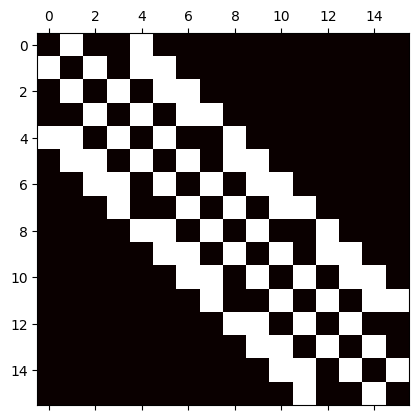

In [236]:
im = plt.matshow(M, cmap="hot")
# plt.colorbar(im)

In [237]:
check_connections(m=5, N=N, connections=connections[5])

array([9, 8, 6, 4, 2, 1])

In [238]:
nmax = 4
N = nmax ** 2
connections_pbc = {
    n: [
        (n + nmax) % N, 
        (n + nmax - 1) % N, 
        (n + 1) % N, 
        (n - 1) % N, 
        (n - nmax + 1) % N, 
        (n - nmax) % N
        ] for n in range(N)
}
M_PBC = np.zeros((N, N))

for key, value in connections_pbc.items():
    M_PBC[key, value] = 1

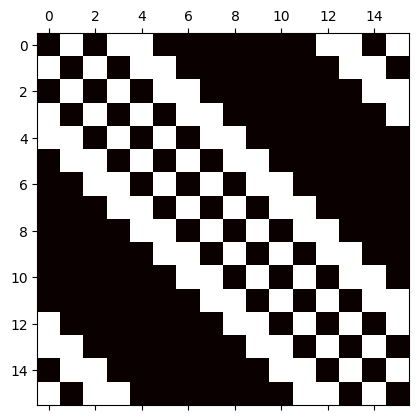

In [239]:
plt.matshow(M_PBC, cmap="hot")

In [183]:
m = 5
c = np.arange(N)[connections[m]]

site_row = m // nmax
same_rows = (c // nmax) == site_row
next_rows = np.abs((c // nmax) - site_row) == 1
distance_row = np.abs(c - m) == 1

c[(same_rows & distance_row) | next_rows]

array([9, 8, 6, 4, 2, 1])

## PBC y

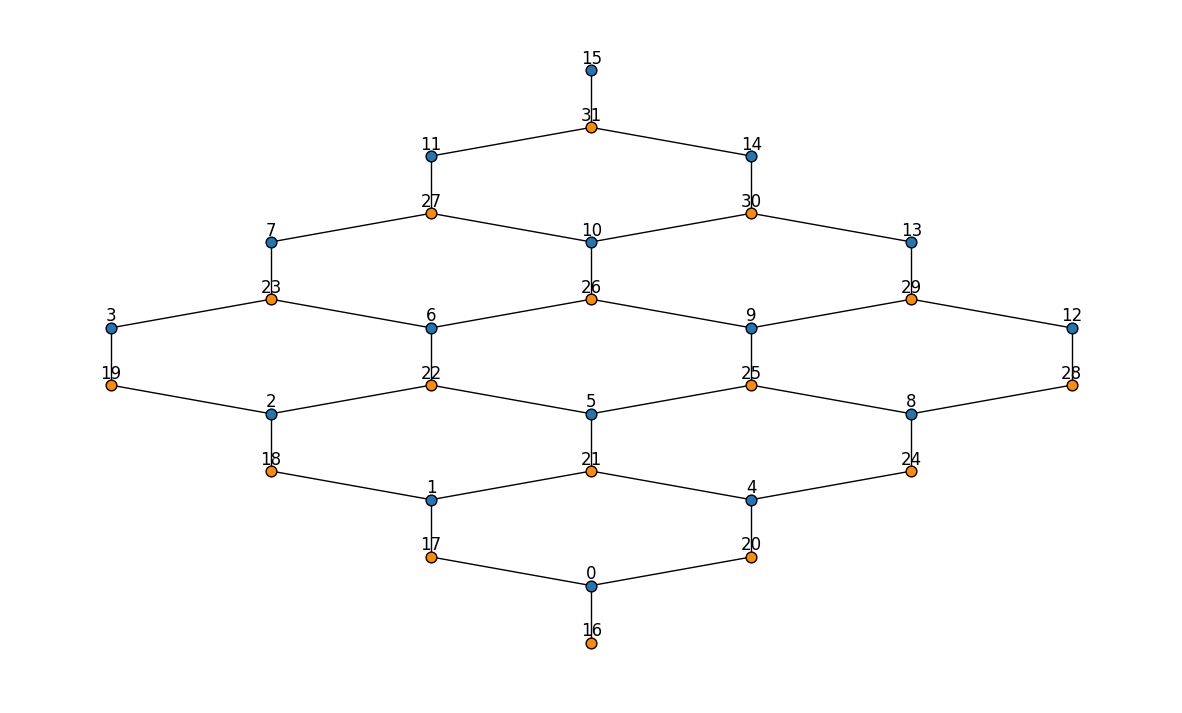

In [8]:
# print(connections[0])
lattice=Graphene(nmax=4, J_prime=0, pbc=None)
fig, _ = lattice.plot(True)

In [17]:
G = lattice.graph

In [19]:
G.edges(11)

EdgeDataView([(11, 7), (11, 10), (11, 14), (11, 15), (11, 27), (11, 31)])

## PBC x

In [ ]:
lattice=Graphene(nmax=4, pbc="x")
fig, _ = lattice.plot(True, theta_rot=np.pi/3)

NameError: name 'connections' is not defined

array([[[1, 2],
        [3, 4]]])

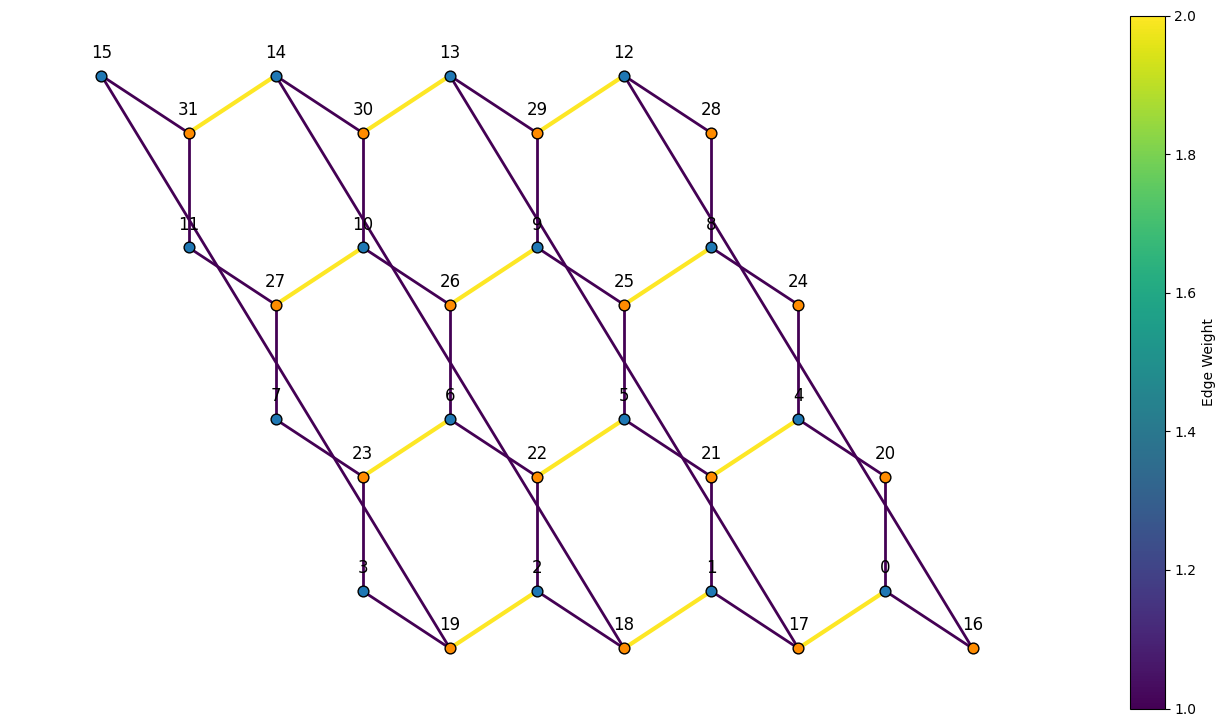

In [21]:
# print(connections[0])
lattice=Graphene(nmax=4, pbc="y", anisotropy_J=2)
fig, _ = lattice.plot(True, theta_rot=np.pi/3, color_by_weight=True)

# fig.savefig("graphene.svg")

In [31]:
lattice=Graphene(nmax=4, J_prime=-1, pbc=None)


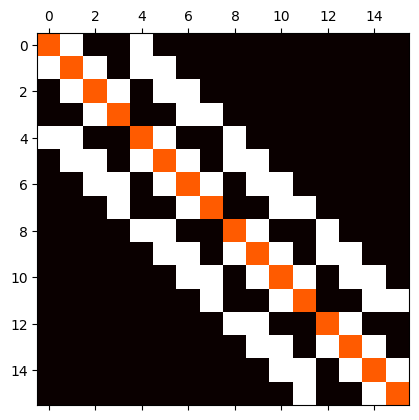

In [ ]:
# Non PBC
nmax = 4

def build_diag(ki):
    k = np.full(nmax ** 2 - ki, 1.)
    
    if ki == 1:
      k[nmax-1::nmax] = 0
      return k
    
    if ki == nmax - 1:
       k[::nmax] = 0
       return k
    
    if ki == (2 * nmax - 1):
       k[:] = 0
       k[::nmax] = 1.
       return k

    return k


energy = np.full(nmax ** 2, 0.5)

ks = [1, nmax - 1, nmax]
k = [build_diag(ki) for ki in ks]
offsets = ks + [-ki for ki in ks]

M = diags([energy] + k * 2, offsets=[0] + offsets)

plt.matshow(M.todense(), cmap="hot")

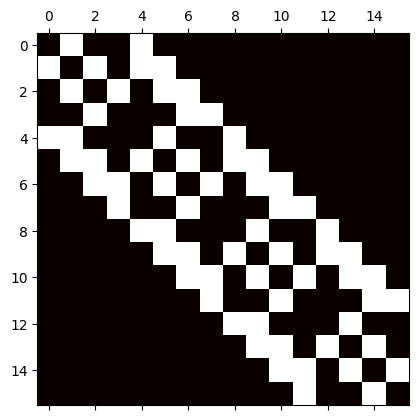

In [281]:
# Non PBC

nmax = 4


k1 = np.full(nmax ** 2 - 1, 1.)
k1[nmax-1::nmax] = 0 # k = 1 


k3 = np.full(nmax ** 2 - (nmax - 1), 1.)
k3[::nmax] = 0 # k = 3 


k4 = np.full(nmax ** 2 - nmax, 1.)

M = diags([k1, k3, k4] * 2, offsets=[1, nmax - 1, nmax, -1, -(nmax-1), - nmax])

plt.matshow(M.todense(), cmap="hot")

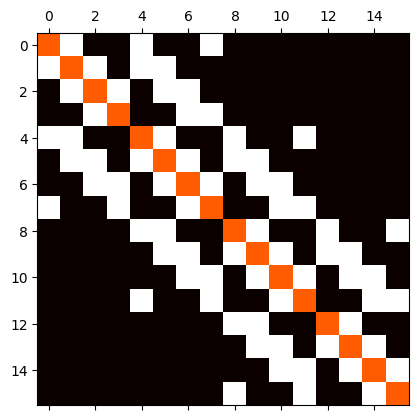

In [ ]:
# PBC X

energy = np.full(nmax ** 2, 0.5)

ks = [1, nmax - 1, nmax, 2 * nmax - 1]
k = [build_diag(ki) for ki in ks]
offsets = ks + [-ki for ki in ks]

M = diags([energy] + k * 2, offsets=[0] + offsets)

plt.matshow(M.todense(), cmap="hot")

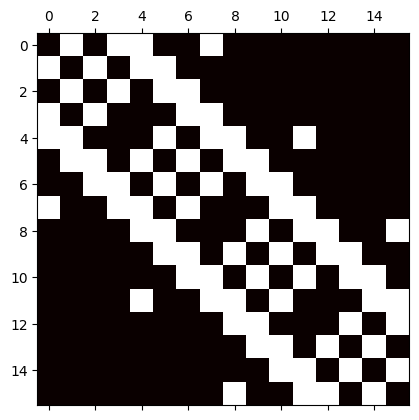

In [ ]:
# PBC X

nmax = 4

k1 = np.full(nmax ** 2 - 1, 1.)
k1[nmax-1::nmax] = 0 # k = 1 


k3 = np.full(nmax ** 2 - (nmax - 1), 1.)
k4 = np.full(nmax ** 2 - nmax, 1.)

k7 = np.zeros(nmax ** 2 - (2 * nmax - 1))
k7[::nmax] = 1


M = diags([k1, k3, k4, k7] * 2, offsets=[1, (nmax - 1), nmax, (2 * nmax - 1), -1, -(nmax - 1), -nmax, -(2 * nmax - 1)])

plt.matshow(M.todense(), cmap="hot")

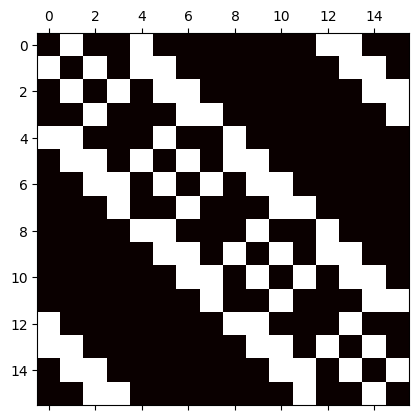

In [59]:
# PBC Y

energy = np.full(nmax ** 2, 0.)

ks = [1, nmax - 1, nmax, nmax * (nmax - 1), nmax * (nmax - 1) + 1]
k = [build_diag(ki) for ki in ks]
offsets = ks + [-ki for ki in ks]

M = diags([energy] + k * 2, offsets=[0] + offsets)

plt.matshow(M.todense(), cmap="hot")

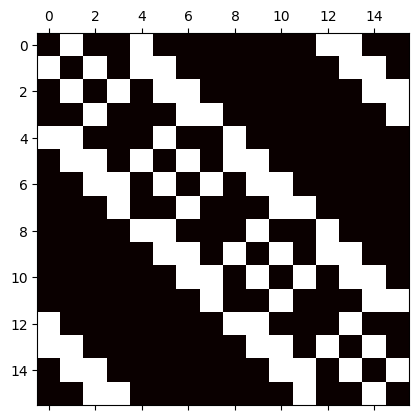

In [ ]:

PBC = "y"
nmax = 4

ks = [1, nmax - 1, nmax]
kextra = []

if PBC == "y":
    kextra = [nmax * (nmax - 1), nmax * (nmax - 1) + 1]

if PBC == "x":
    kextra = [2 * nmax - 1]

if PBC == "xy":
    kextra = [nmax * (nmax - 1), nmax * (nmax - 1) + 1, 2 * nmax - 1]

ks += kextra
ksm = [-k for k in ks]

K = [np.full(nmax ** 2 - k, 1.)for k in ks]

K[0][nmax-1::nmax] = 0
K[1][::nmax] = 0
if PBC == ("x" or "xy"):
    K[1] = 1.
    K[-1] = np.zeros(nmax ** 2 - (2 * nmax - 1))
    K[-1][::nmax] = 1.
    
K = K * 2
ks = ks + ksm

M = diags(K, offsets=ks)

plt.matshow(M.todense(), cmap="hot")

In [291]:
nmax ** 2 - nmax

12

In [ ]:
k11 = np.full()